In [1]:
# Cell 1 — imports
import json, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import joblib, os

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

In [2]:
# Cell 2 — load results
with open("../artifacts/reports/drift_scores.json") as f:
    drift = json.load(f)

with open("../artifacts/reports/cross_eval_accuracy.json") as f:
    evals = json.load(f)

df_drift = pd.DataFrame(drift)
df_eval  = pd.DataFrame(evals)

# Short labels for plots
short = {
    "Monday-WorkingHours.pcap_ISCX.csv"                        : "Mon",
    "Tuesday-WorkingHours.pcap_ISCX.csv"                       : "Tue",
    "Wednesday-workingHours.pcap_ISCX.csv"                     : "Wed",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv"   : "Thu AM",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv": "Thu PM",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv"                : "Fri AM",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv"     : "Fri Port",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"         : "Fri DDoS",
}
df_eval["label"] = df_eval["batch"].map(short)
df_drift["label"] = df_drift["comparison_batch"].map(short)

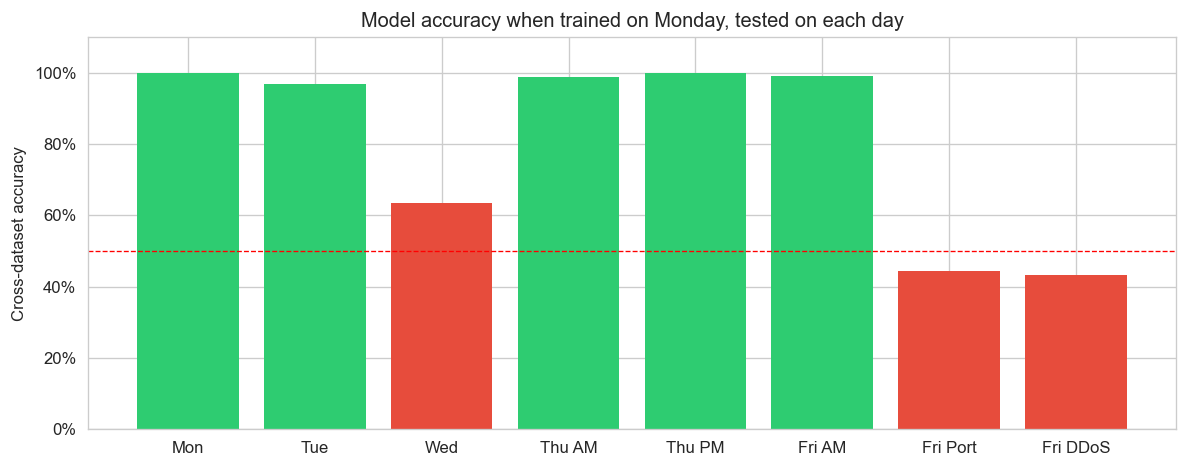

In [3]:
# Cell 3 — Figure 1: accuracy per batch
fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#2ecc71" if a > 0.95 else "#f39c12" if a > 0.7 else "#e74c3c"
          for a in df_eval["accuracy"]]
ax.bar(df_eval["label"], df_eval["accuracy"] * 100, color=colors, edgecolor="none")
ax.axhline(50, color="red", linewidth=0.8, linestyle="--", label="50% threshold")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel("Cross-dataset accuracy")
ax.set_title("Model accuracy when trained on Monday, tested on each day")
ax.set_ylim(0, 110)
plt.tight_layout()
plt.savefig("../artifacts/reports/fig1_accuracy_per_batch.png", dpi=150)
plt.show()

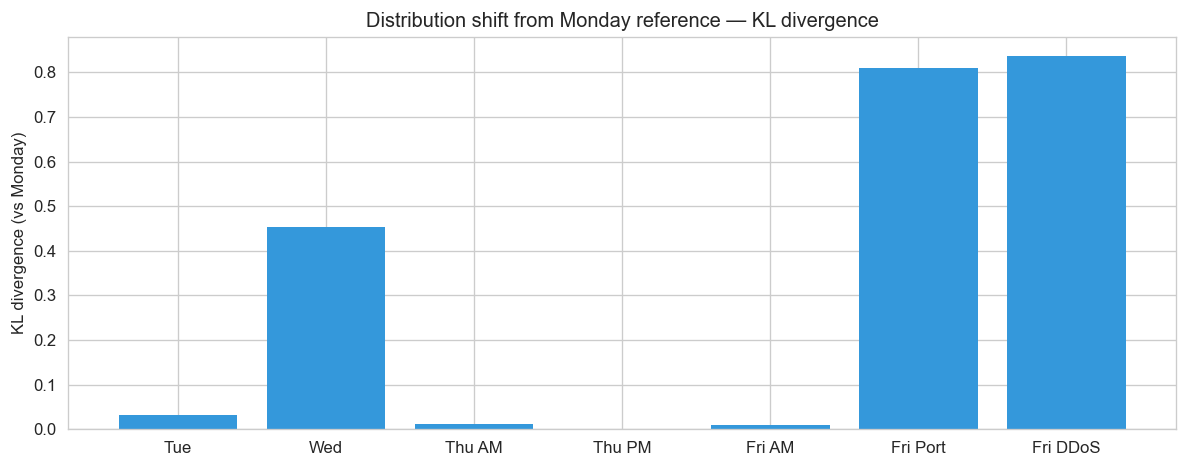

In [4]:
# Cell 4 — Figure 2: KL divergence per batch
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(df_drift["label"], df_drift["label_kl_divergence"],
       color="#3498db", edgecolor="none")
ax.set_ylabel("KL divergence (vs Monday)")
ax.set_title("Distribution shift from Monday reference — KL divergence")
plt.tight_layout()
plt.savefig("../artifacts/reports/fig2_kl_divergence.png", dpi=150)
plt.show()

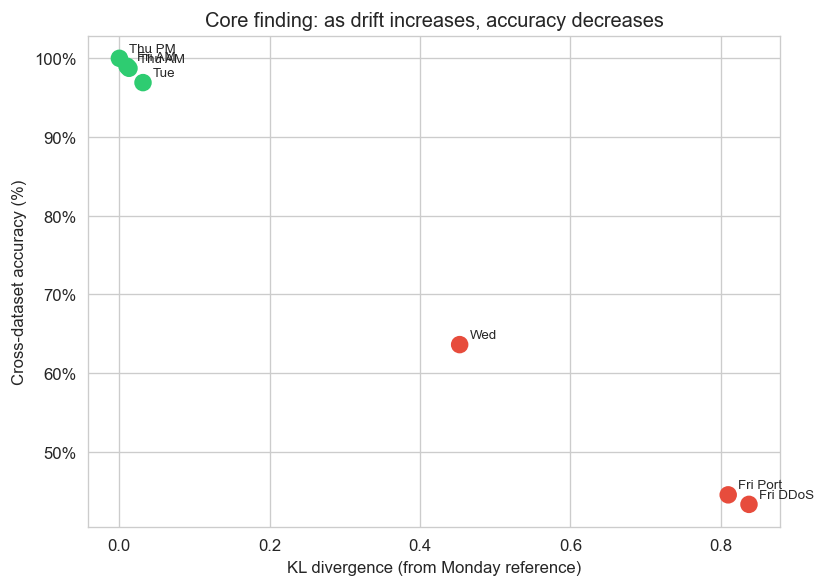

In [5]:
# Cell 5 — Figure 3: scatter — KL vs accuracy (the key finding)
merged = df_drift.merge(
    df_eval[["label","accuracy"]], on="label", how="inner"
)
fig, ax = plt.subplots(figsize=(7, 5))
colors_s = ["#2ecc71" if a > 0.95 else "#f39c12" if a > 0.7 else "#e74c3c"
            for a in merged["accuracy"]]
ax.scatter(merged["label_kl_divergence"], merged["accuracy"] * 100,
           s=90, c=colors_s, zorder=5)
for _, row in merged.iterrows():
    ax.annotate(row["label"],
                (row["label_kl_divergence"], row["accuracy"]*100),
                textcoords="offset points", xytext=(6, 4), fontsize=8)
ax.set_xlabel("KL divergence (from Monday reference)")
ax.set_ylabel("Cross-dataset accuracy (%)")
ax.set_title("Core finding: as drift increases, accuracy decreases")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.savefig("../artifacts/reports/fig3_kl_vs_accuracy.png", dpi=150)
plt.show()

C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator LinearRegression from version 1.8.0 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


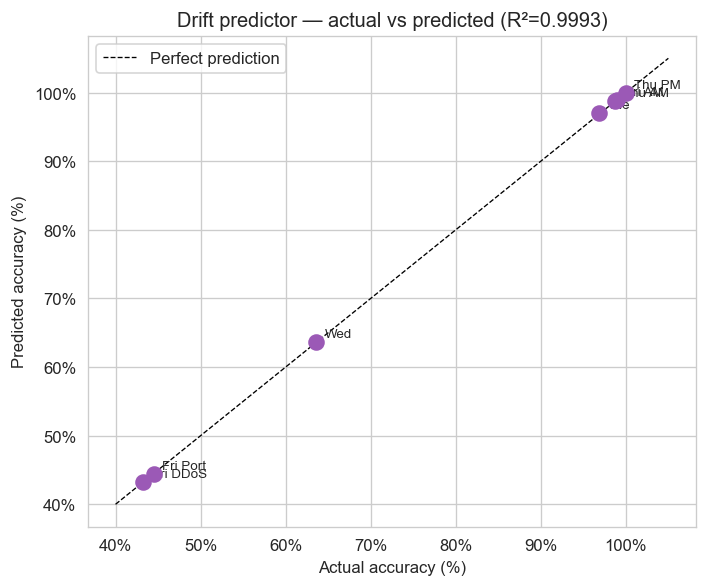

In [6]:
# Cell 6 — Figure 4: predicted vs actual
model = joblib.load("../artifacts/model/drift_predictor_linear_regression.pkl")
X = merged[["label_kl_divergence","label_js_divergence","mean_feature_js"]].values
predicted = model.predict(X)

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(merged["accuracy"]*100, predicted*100, s=80, color="#9b59b6", zorder=5)
ax.plot([40,105],[40,105], "k--", linewidth=0.8, label="Perfect prediction")
for i, row in merged.iterrows():
    ax.annotate(row["label"],
                (row["accuracy"]*100, predicted[i]*100),
                textcoords="offset points", xytext=(5, 3), fontsize=8)
ax.set_xlabel("Actual accuracy (%)")
ax.set_ylabel("Predicted accuracy (%)")
ax.set_title("Drift predictor — actual vs predicted (R²=0.9993)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend()
plt.tight_layout()
plt.savefig("../artifacts/reports/fig4_predicted_vs_actual.png", dpi=150)
plt.show()

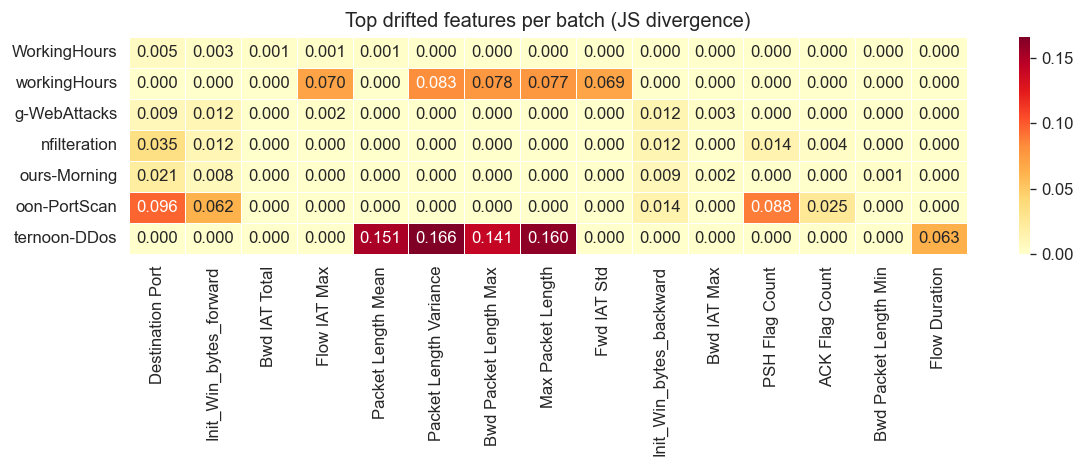

In [7]:
# Cell 7 — Feature drift heatmap (top drifted features)
feat_data = {}
for rec in drift:
    feat_data[rec["comparison_batch"].split(".")[0][-12:]] = rec["top_drifted_features"]

feat_df = pd.DataFrame(feat_data).T.fillna(0)
fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(feat_df, annot=True, fmt=".3f", cmap="YlOrRd", ax=ax, linewidths=0.5)
ax.set_title("Top drifted features per batch (JS divergence)")
plt.tight_layout()
plt.savefig("../artifacts/reports/fig5_feature_drift_heatmap.png", dpi=150)
plt.show()

In [8]:
# Cell 8 — print summary table
print("=" * 75)
print(f"{'Batch':<12} {'KL':>8} {'JS':>8} {'Actual Acc':>12} {'Pred Acc':>10} {'Error':>8}")
print("-" * 75)
for i, row in merged.iterrows():
    err = abs(row["accuracy"] - predicted[i])
    print(f"{row['label']:<12} {row['label_kl_divergence']:>8.4f} "
          f"{row['label_js_divergence']:>8.4f} "
          f"{row['accuracy']*100:>11.2f}% "
          f"{predicted[i]*100:>9.2f}% "
          f"{err*100:>7.2f}%")
print("=" * 75)

Batch              KL       JS   Actual Acc   Pred Acc    Error
---------------------------------------------------------------------------
Tue            0.0315   0.0109       96.90%     96.99%    0.09%
Wed            0.4527   0.1466       63.59%     63.58%    0.01%
Thu AM         0.0129   0.0045       98.72%     98.72%    0.00%
Thu PM         0.0001   0.0000       99.99%     99.92%    0.07%
Fri AM         0.0103   0.0036       98.98%     98.97%    0.01%
Fri Port       0.8098   0.2471       44.49%     44.47%    0.02%
Fri DDoS       0.8375   0.2543       43.28%     43.30%    0.02%
